# Avance 2 – Ingeniería de Características  
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

**Variable objetivo:** `group` con tres clases clínicas: `CTRL`, `AA` y `CRC`.

**Continuidad con Avance 1:** Esta libreta parte del mismo conjunto de datos, la misma reconstrucción de encabezados, la misma depuración inicial y las observaciones del EDA. El objetivo de este avance es convertir el dataset depurado en una matriz de características útil para modelos supervisados.

## Objetivos del Avance 2

De acuerdo con la actividad de **Ingeniería de Características**, esta libreta cubre:

1. **Construcción de características**
   - Decisión justificada sobre cuándo crear nuevas variables (ratios metabólicos) y cuándo no hacerlo (agregados por familia, atributos estructurales) para evitar sobre-ingeniería.
   - Codificación de variables categóricas mediante técnicas adecuadas (One-Hot Encoding).

2. **Normalización y transformación**
   - Escalamiento (StandardScaler) sobre variables continuas tras transformación.
   - Transformación Box-Cox sobre lípidos y variables clínicas positivas.
   - Justificación de cada técnica empleada.

3. **Selección y extracción de características**
   - Filtros: correlación, Mutual Information, ANOVA F-test, Chi-cuadrado.
   - PCA como herramienta exploratoria (no matriz finalista).
   - Construcción de la matriz `X_intersect` con biomarcadores robustos bajo dos criterios supervisados independientes.

4. **Conclusión CRISP-ML(Q)**
   - Cierre de la fase de preparación de datos con quality gates explícitas.


## 1. Configuración inicial

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, shapiro, boxcox

from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer,
    KBinsDiscretizer,
    LabelEncoder
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    f_classif,
    chi2
)

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

RANDOM_STATE = 42

print('Setup listo.')

Setup listo.


## 2. Carga del dataset y reconstrucción de encabezados

El archivo original contiene filas de metadatos que describen familias, subfamilias y nombres de metabolitos. Para mantener continuidad con el Avance 1, se reconstruyen los encabezados de forma controlada y se conserva una tabla de metadatos de variables.

In [2]:
# Localizar el archivo del dataset con busqueda automatica.
# Funciona tanto en local como en Google Colab.
import os

FILENAME = 'BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv'

candidate_paths = [
    # Local (estructura del repo)
    f'./data/{FILENAME}',
    f'../data/{FILENAME}',
    f'./{FILENAME}',
    f'../{FILENAME}',
    # Repo en Documents
    f'/Users/sofiaordazlopez/Documents/Proyecto Integrador/{FILENAME}',
    f'/Users/sofiaordazlopez/Documents/Proyecto Integrador/data/{FILENAME}',
    # Colab
    f'/content/drive/MyDrive/Proyecto Integrador/{FILENAME}',
    f'/content/{FILENAME}',
]

file_path = None
for path in candidate_paths:
    if os.path.exists(path):
        file_path = path
        break

# Fallback
if file_path is None:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=True)
        candidate = f'/content/drive/MyDrive/Proyecto Integrador/{FILENAME}'
        if os.path.exists(candidate):
            file_path = candidate
    except ImportError:
        pass

if file_path is None:
    raise FileNotFoundError(
        f'No se encontro {FILENAME} en ninguna ubicacion conocida. '
        f'Verifica que el archivo este en ./data/ o ajusta candidate_paths.'
    )

print(f'Archivo localizado: {file_path}')


Archivo localizado: ../data/BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv


In [3]:
raw = pd.read_csv(file_path, encoding='latin1', header=None)

metadata_rows = raw.iloc[0:4, :].copy()
data = raw.iloc[4:, :].copy().reset_index(drop=True)

families = metadata_rows.iloc[0, :].ffill()
subfamilies = metadata_rows.iloc[1, :]
metabolite_names = metadata_rows.iloc[2, :]
probable_ids = metadata_rows.iloc[3, :]

# Unificar etiqueta con typo observada en el Avance 1
families = families.astype('object').replace({
    'GLYCEROPHOSPHOLIPID': 'GLYCEROPHOSPHOLIPIDS'
})

base_names = {
    0: 'sample',
    1: 'sample_id',
    2: 'group',
    3: 'gender',
    4: 'fob',
    5: 'age',
    6: 'fit_ug_g',
    7: 'z_age',
    8: 'z_fob',
    9: 'age_standardized',
    10: 'fit_standardized'
}

new_cols = []
seen = {}

for i in range(raw.shape[1]):
    if i in base_names:
        col = base_names[i]
    else:
        name = metabolite_names.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = subfamilies.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = f'feature_{i}'
        col = re.sub(r'\s+', ' ', str(name).strip())
        if col in seen:
            seen[col] += 1
            col = f'{col}__dup{seen[col]}'
        else:
            seen[col] = 0
    new_cols.append(col)

data.columns = new_cols

feature_metadata = []
for i, col in enumerate(new_cols):
    if i >= 11:
        feature_metadata.append({
            'column': col,
            'family': str(families.iloc[i]).strip() if pd.notna(families.iloc[i]) else 'Unknown',
            'subfamily': str(subfamilies.iloc[i]).strip() if pd.notna(subfamilies.iloc[i]) else 'Unknown',
            'notation': str(metabolite_names.iloc[i]).strip() if pd.notna(metabolite_names.iloc[i]) else col,
            'probable_id': str(probable_ids.iloc[i]).strip() if pd.notna(probable_ids.iloc[i]) else ''
        })

feature_metadata = pd.DataFrame(feature_metadata)

print(f'Dimensiones del archivo reconstruido: {data.shape}')
print(f'Variables lipidómicas/metabolómicas catalogadas: {len(feature_metadata)}')
display(feature_metadata.head())

Dimensiones del archivo reconstruido: (211, 138)
Variables lipidómicas/metabolómicas catalogadas: 127


,column,family,subfamily,notation,probable_id
0,Cer(d18:1/16:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/16:0),
1,Cer(d18:1/20:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/20:0),
2,Cer(d18:1/22:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/22:0),
3,Cer(d18:1/23:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/23:0),
4,Cer(d18:1/24:0),SPHINGOLIPIDS,Ceramides,Cer(d18:1/24:0),


## 3. Limpieza inicial y separación de variables

### Justificación

Se eliminan identificadores y versiones estandarizadas heredadas del archivo original para evitar ruido y duplicidad. Las versiones estandarizadas (`z_age`, `z_fob`, `age_standardized`, `fit_standardized`) no deben coexistir con las variables originales porque podrían introducir redundancia y afectar indebidamente los análisis posteriores.

El escalamiento se realizará más adelante dentro de esta libreta, de forma explícita y documentada.

In [4]:
# Normalizar variables categóricas
for col in ['group', 'gender', 'fob']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace({'nan': np.nan, '': np.nan})

# Eliminar identificadores y variables redundantes/ya estandarizadas
columns_to_drop = [
    'sample_id',
    'z_age',
    'z_fob',
    'age_standardized',
    'fit_standardized'
]

data = data.drop(columns=[c for c in columns_to_drop if c in data.columns])

# Convertir variables numéricas
id_and_label_cols = ['sample', 'group', 'gender', 'fob']
for col in data.columns:
    if col not in id_and_label_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['group']).reset_index(drop=True)

target_col = 'group'
clinical_numeric_cols = [c for c in ['age', 'fit_ug_g'] if c in data.columns]
categorical_cols = [c for c in ['gender', 'fob'] if c in data.columns]
lipid_cols = [c for c in feature_metadata['column'].tolist() if c in data.columns]

print('Dimensiones tras limpieza inicial:', data.shape)
print('Variables clínicas numéricas:', clinical_numeric_cols)
print('Variables categóricas:', categorical_cols)
print('Variables lipídicas/metabolómicas:', len(lipid_cols))
print('\nDistribución del target:')
display(data[target_col].value_counts().to_frame('n'))

Dimensiones tras limpieza inicial: (211, 133)
Variables clínicas numéricas: ['age', 'fit_ug_g']
Variables categóricas: ['gender', 'fob']
Variables lipídicas/metabolómicas: 127

Distribución del target:


,n
group,
CTRL,78
CRC,75
AA,58


## 4. Diccionario de variables por familia

### Justificación

Esta tabla permite documentar qué variables corresponden a cada familia lipidómica/metabolómica y facilita la interpretación de las nuevas características construidas.

In [5]:
variable_dictionary = (
    feature_metadata[feature_metadata['column'].isin(lipid_cols)]
    .groupby(['family', 'subfamily'])
    .agg(
        n_variables=('column', 'count'),
        examples=('column', lambda x: ', '.join(list(x)[:5]))
    )
    .reset_index()
    .sort_values(['family', 'subfamily'])
)

display(variable_dictionary)

,family,subfamily,n_variables,examples
0,GLYCEROLIPIDS,Diacylglycerols,8,"DG(32:1), DG(34:0), DG(34:1), DG(34:2), DG(36:2)"
1,GLYCEROLIPIDS,Monoacylglycerols,1,MG(18:0/0:0/0:0)
2,GLYCEROLIPIDS,Triacylglycerols,51,"TG(51:0), TG(42:0), TG(46:1), TG(46:2), TG(46:3)"
3,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphocholine",8,"PC(O-16:0/16:0), PC(O-34:1), PC(O-16:0/18:2), ..."
4,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphoethanolamine",4,"PE(O-16:0/18:1), PE(P-16:0/18:2), PE(P-18:0/18..."
5,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphocholine,17,"PC(32:0), PC(32:1), PC(34:0), PC(34:1), PC(34:2)"
6,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphoethanolamine,6,"PE(34:1), PE(34:2), PE(36:3), PE(36:4), PE(36:..."
7,SPHINGOLIPIDS,Ceramides,7,"Cer(d18:1/16:0), Cer(d18:1/20:0), Cer(d18:1/22..."
8,SPHINGOLIPIDS,Monohexosylceramides,2,"GlcCer(d18:1/22:0), GlcCer(d18:1/24:0)"
9,SPHINGOLIPIDS,Sphingomyelin,14,"SM(d18:0/16:0), SM(d18:0/18:0), SM(d18:0/22:0)..."


## 5. Preparación base para ingeniería de características

### 5.1 Filtrado por missingness

Se eliminan lípidos/metabolitos con más de 40% de valores faltantes. Esta decisión proviene del Avance 1 y busca evitar que variables con demasiada ausencia introduzcan inestabilidad en la construcción de características y selección posterior.

In [6]:
missing_threshold = 0.40

lipids_to_drop = [
    c for c in lipid_cols
    if data[c].isna().mean() > missing_threshold
]

lipids_kept = [
    c for c in lipid_cols
    if c not in lipids_to_drop
]

print(f'Lípidos eliminados por >40% missing: {len(lipids_to_drop)}')
print(f'Lípidos retenidos: {len(lipids_kept)}')
display(pd.DataFrame({
    'lipid_removed': lipids_to_drop,
    'missing_rate': [data[c].isna().mean() for c in lipids_to_drop]
}).sort_values('missing_rate', ascending=False))

Lípidos eliminados por >40% missing: 5
Lípidos retenidos: 122


,lipid_removed,missing_rate
0,PC(33:0),0.535545
3,SM(36:2),0.521327
1,PE(P-18:0/20:4),0.516588
4,TG(55:2),0.483412
2,SM(d18:1/17:0),0.426540


### 5.2 Imputación por mediana de grupo

### Justificación

Se aplica imputación por mediana dentro de cada grupo clínico (`CTRL`, `AA`, `CRC`) para conservar la estructura clínica del dataset y evitar que la imputación global diluya diferencias entre grupos. La mediana es robusta ante valores extremos y es adecuada para datos biomédicos con distribuciones asimétricas.

In [7]:
data_imputed = data.copy()

for col in lipids_kept:
    medians_by_group = data.groupby(target_col)[col].transform('median')
    data_imputed[col] = data[col].fillna(medians_by_group)

# Fallback de seguridad: mediana global si quedara algún NaN
for col in lipids_kept:
    if data_imputed[col].isna().any():
        data_imputed[col] = data_imputed[col].fillna(data[col].median())

# Clínicas numéricas
for col in clinical_numeric_cols:
    if data_imputed[col].isna().any():
        data_imputed[col] = data_imputed[col].fillna(data_imputed[col].median())

print('NaN restantes en lípidos retenidos:', data_imputed[lipids_kept].isna().sum().sum())
print('NaN restantes en clínicas numéricas:', data_imputed[clinical_numeric_cols].isna().sum().sum())

NaN restantes en lípidos retenidos: 0
NaN restantes en clínicas numéricas: 0


### 5.3 Validación de imputación mediante correlación

### Justificación

Para evitar que la imputación altere sustancialmente la estructura de relaciones entre metabolitos, se comparan matrices de correlación antes y después de imputar. Una diferencia moderada respalda que la imputación preserva de forma razonable la estructura del dataset.

In [8]:
corr_pre = data[lipids_kept].corr()
corr_post = data_imputed[lipids_kept].corr()
corr_diff = corr_post - corr_pre

frobenius_norm = np.linalg.norm(corr_diff.fillna(0).values, ord='fro')
max_abs_diff = corr_diff.abs().max().max()
mean_abs_diff = corr_diff.abs().mean().mean()

print(f'Norma de Frobenius de diferencia: {frobenius_norm:.4f}')
print(f'Diferencia absoluta máxima: {max_abs_diff:.4f}')
print(f'Diferencia absoluta promedio: {mean_abs_diff:.4f}')

Norma de Frobenius de diferencia: 3.2364
Diferencia absoluta máxima: 0.3577
Diferencia absoluta promedio: 0.0107


In [9]:
# Validacion complementaria: comparacion contra MICE (IterativeImputer).
# Se contrasta cuantitativamente que estrategia preserva mejor la estructura de correlacion
# pre-imputacion (calculada con pares completos como referencia).
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

data_mice = data.copy()
mice_imputer = IterativeImputer(
    max_iter=10, random_state=RANDOM_STATE,
    sample_posterior=False, initial_strategy='median',
)
data_mice[lipids_kept] = mice_imputer.fit_transform(data[lipids_kept])

corr_mice = data_mice[lipids_kept].corr()
diff_mice = corr_mice - corr_pre
frob_mice = np.linalg.norm(diff_mice.fillna(0).values, ord='fro')
max_mice = diff_mice.abs().max().max()
mean_mice = diff_mice.abs().mean().mean()
n_pairs = len(lipids_kept) ** 2

comparison = pd.DataFrame({
    'metrica': [
        'Norma de Frobenius (||corr_imp - corr_pre||)',
        'Maxima |delta r|',
        'Media |delta r|',
        'Pares con |delta r| > 0.05',
        'Pares con |delta r| > 0.10',
    ],
    'mediana_por_grupo': [
        f'{frobenius_norm:.4f}', f'{max_abs_diff:.4f}', f'{mean_abs_diff:.4f}',
        f'{(corr_diff.abs() > 0.05).sum().sum()} / {n_pairs}',
        f'{(corr_diff.abs() > 0.10).sum().sum()} / {n_pairs}',
    ],
    'MICE_IterativeImputer': [
        f'{frob_mice:.4f}', f'{max_mice:.4f}', f'{mean_mice:.4f}',
        f'{(diff_mice.abs() > 0.05).sum().sum()} / {n_pairs}',
        f'{(diff_mice.abs() > 0.10).sum().sum()} / {n_pairs}',
    ],
})
print('Comparativa: mediana por grupo vs MICE — preservacion de la estructura de correlacion')
display(comparison)


Comparativa: mediana por grupo vs MICE — preservacion de la estructura de correlacion


,metrica,mediana_por_grupo,MICE_IterativeImputer
0,Norma de Frobenius (||corr_imp - corr_pre||),3.2364,13.5848
1,Maxima |delta r|,0.3577,1.0295
2,Media |delta r|,0.0107,0.0496
3,Pares con |delta r| > 0.05,556 / 14884,3708 / 14884
4,Pares con |delta r| > 0.10,238 / 14884,2256 / 14884


**Lectura del resultado:**

La **mediana por grupo gana en todas las métricas**: Frobenius ≈ 4× menor (3.24 vs 13.58), media \|Δr\| ≈ 5× menor (0.011 vs 0.050) y los pares con \|Δr\| > 0.10 representan 1.6% del total con mediana por grupo frente a 15.2% con MICE.

**Razón metodológica:** MICE modela las regresiones iterativas sin incorporar la etiqueta de grupo. Como el análisis del missingness (Avance 1) confirmó dependencia significativa con el grupo (MAR/MNAR), MICE diluye la señal específica por clase al imputar; la mediana por grupo, en contraste, preserva la separación por diseño.

**Decisión:** se mantiene `data_imputed` (mediana por grupo) como entrada para el resto del pipeline. El detalle visual completo (mapas de calor pre / mediana / MICE / Δ) se documenta en el Avance 1 como mejora complementaria al EDA.


## 6. Construcción de características

### Fundamentación de dominio y criterio de no sobre-ingeniería

En lipidómica, **cada lípido cuantificado por UHPLC-MS es ya un biomarcador medido directamente**, no un constructo derivado. Una pregunta legítima en feature engineering es si **agregar** estos biomarcadores en variables resumen (medias o sumas por familia, ratios entre grupos químicos, atributos estructurales como longitud media de cadena) produce señal predictiva adicional.

El Avance 1 evaluó esta hipótesis empíricamente sobre atributos estructurales agregados (`mean_chain_length`, `mean_unsaturation`, `plasmalogen_frac`) mediante información mutua y concluyó que **no aportan capacidad predictiva incremental** frente a los lípidos individuales (todas con posición > #85 en el ranking de MI). La razón identificada fue que **el promedio sobre una familia diluye la señal discriminativa específica** que reside en lípidos individuales.

**Decisión metodológica para este Avance 2:** no se reincorporan los atributos estructurales ni se construyen agregados redundantes por familia o subfamilia. La información biológica relevante ya está representada en sus tres formas naturales:

1. **Variables clínicas** (`age`, `fit_ug_g`) que aportan contexto demográfico y un biomarcador clínico estándar (FIT).
2. **Variables categóricas** (`gender`, `fob`) que se codifican adecuadamente.
3. **122 lípidos individuales** retenidos tras el filtrado de missingness — cada uno es una medición directa con interpretabilidad bioquímica.

**Excepción justificada — ratios metabólicos (sección 6.1):** los ratios entre familias lipídicas son cualitativamente distintos a los agregados, ya que capturan **balances proporcionales** (no sumas absolutas) entre rutas metabólicas. Un ratio como `TG/PC` describe el equilibrio entre almacenamiento energético y estructura de membrana, información que no aparece explícitamente al observar cada lípido por separado. Se construyen únicamente cinco ratios con interpretación biomédica directa, evitando expandir el espacio de features innecesariamente.

**Codificación categórica (sección 6.2):** se aplica One-Hot Encoding a `gender` y `fob` para incorporarlas a algoritmos que requieren entradas numéricas, sin imponer orden artificial entre categorías nominales.


### 6.1 Ratios metabólicos interpretables

Se construyen cinco ratios entre sumas de subfamilias lipídicas. Cada ratio se calcula **directamente desde los lípidos individuales retenidos**, sin almacenar las sumas intermedias como columnas adicionales (lo que duplicaría información):

- `TG_PC_ratio` — equilibrio entre triglicéridos (almacenamiento energético) y fosfatidilcolinas (estructura de membrana).
- `SM_CE_ratio` — relación entre esfingomielinas (microdominios lipídicos) y ésteres de colesterol (transporte y reserva).
- `CE_TG_ratio` — balance entre transporte de colesterol y depósito triglicérido.
- `SM_PC_ratio` — proporción entre componentes esfingomielínicos y fosfocolinas en la membrana.
- `PE_PC_ratio` — relación entre fosfatidiletanolaminas y fosfatidilcolinas (curvatura y fluidez de membrana).

**Sustento biomédico (consulta con equipo clínico):** los balances entre estas familias son los que la literatura reporta como relevantes en cáncer colorrectal. La acumulación de ésteres de colesterol y esfingomielinas en CRC se documenta como mecanismo de progresión tumoral (sobreexpresión de ACAT1 y alteración de microdominios de membrana), mientras que la disminución de triglicéridos poliinsaturados refleja reprogramación metabólica para nutrir la división celular acelerada y evadir ferroptosis (Li et al., 2026; Machala et al., 2019; Li et al., 2023; Terry & Hay, 2024). Por esta razón, los ratios entre subfamilias capturan información proporcional con interpretación bioquímica directa que las variables individuales no codifican explícitamente.

Los ratios se calculan sobre la lista `lipids_kept` (122 lípidos retenidos tras el filtrado por missingness). Esta aproximación es preferible a guardar las sumas intermedias como columnas porque evita introducir variables intermedias redundantes con las contribuciones individuales.


In [10]:
# Construir feature_data partiendo de data_imputed (mediana por grupo)
feature_data = data_imputed[[target_col] + categorical_cols + clinical_numeric_cols + lipids_kept].copy()

# Definir mapeo prefijo -> lipidos retenidos
prefix_patterns = {
    'TG': r'^TG',
    'PC': r'^PC',
    'PE': r'^PE',
    'SM': r'^SM',
    'CE': r'^CE',
}
subfamily_cols_map = {}
for prefix, pattern in prefix_patterns.items():
    cols = [c for c in lipids_kept if re.search(pattern, c)]
    if cols:
        subfamily_cols_map[prefix] = cols

ratio_features = []

def add_ratio(num_prefix, den_prefix, ratio_name):
    """Calcula la suma local de cada prefijo sobre los lipidos retenidos y construye el ratio."""
    if num_prefix in subfamily_cols_map and den_prefix in subfamily_cols_map:
        num_sum = feature_data[subfamily_cols_map[num_prefix]].sum(axis=1)
        den_sum = feature_data[subfamily_cols_map[den_prefix]].sum(axis=1)
        feature_data[ratio_name] = num_sum / (den_sum + 1e-10)
        ratio_features.append(ratio_name)

add_ratio('TG', 'PC', 'TG_PC_ratio')
add_ratio('SM', 'CE', 'SM_CE_ratio')
add_ratio('CE', 'TG', 'CE_TG_ratio')
add_ratio('SM', 'PC', 'SM_PC_ratio')
add_ratio('PE', 'PC', 'PE_PC_ratio')

print(f'Ratios metabolicos construidos ({len(ratio_features)}): {ratio_features}')
print(f'\nForma de feature_data tras construir ratios: {feature_data.shape}')
display(feature_data[[target_col] + ratio_features].head())

# Estadisticas descriptivas de los ratios
print('\nEstadisticas descriptivas de los ratios:')
display(feature_data[ratio_features].describe().round(3))


Ratios metabolicos construidos (5): ['TG_PC_ratio', 'SM_CE_ratio', 'CE_TG_ratio', 'SM_PC_ratio', 'PE_PC_ratio']

Forma de feature_data tras construir ratios: (211, 132)


,group,TG_PC_ratio,SM_CE_ratio,CE_TG_ratio,SM_PC_ratio,PE_PC_ratio
0,CRC,5.961322,1.231487,0.045403,0.333313,0.389088
1,CTRL,21.411213,0.002708,10.389882,0.602521,8.782113
2,CRC,29.551900,0.048375,0.207628,0.296819,25.437886
3,CRC,36.156391,0.060249,0.094505,0.205868,7.522019
4,CTRL,73.414579,0.064280,0.043689,0.206175,11.320959



Estadisticas descriptivas de los ratios:


,TG_PC_ratio,SM_CE_ratio,CE_TG_ratio,SM_PC_ratio,PE_PC_ratio
count,211.000,211.000,211.000,211.000,211.000
mean,409.041,0.109,0.362,0.471,49.539
std,2107.212,0.169,1.071,0.450,212.847
min,4.102,0.002,0.000,0.083,0.389
25%,26.669,0.024,0.054,0.231,5.266
50%,47.420,0.054,0.131,0.328,10.894
75%,94.278,0.119,0.271,0.533,24.653
max,27234.879,1.231,10.390,3.040,2781.811


### 6.2 Codificación de variables categóricas

Las variables categóricas (`gender`, `fob`) son nominales — no tienen jerarquía natural. Se aplica **One-Hot Encoding** con `drop_first=True`, generando una columna binaria por nivel menos la categoría de referencia para evitar colinealidad perfecta. Esta codificación es adecuada para algoritmos supervisados sin imponer orden artificial entre categorías.


In [11]:
X_base = feature_data.drop(columns=[target_col]).copy()
y = feature_data[target_col].copy()

X_encoded = pd.get_dummies(
    X_base,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

dummy_cols = [c for c in X_encoded.columns if any(c.startswith(f'{cat}_') for cat in categorical_cols)]

print('Variables categóricas originales:', categorical_cols)
print('Columnas dummy creadas:', dummy_cols)
print('Dimensiones después de codificación:', X_encoded.shape)
display(X_encoded[dummy_cols].head())

Variables categóricas originales: ['gender', 'fob']
Columnas dummy creadas: ['gender_Male', 'fob_YES']
Dimensiones después de codificación: (211, 131)


,gender_Male,fob_YES
0,1,0
1,0,1
2,1,1
3,1,1
4,0,0


## 7. Transformación de variables numéricas

### Justificación

El análisis exploratorio del Avance 1 confirmó que los 127 lípidos cuantificados por UHPLC-MS presentan distribuciones **fuertemente asimétricas** (|skewness| mediana = 5.47, todos por encima del umbral 2). Tras evaluar formalmente cuatro alternativas (raw, log1p, Yeo-Johnson, Box-Cox), Box-Cox emergió como la transformación de elección porque:

1. **Positividad estricta** de los lípidos (verificada en el Avance 1): condición que Box-Cox requiere y que se cumple en este conjunto.
2. **Mayor capacidad de normalización**: 81.1% de los lípidos superan el test de Shapiro-Wilk tras Box-Cox vs 5.5% con Yeo-Johnson y 0.8% con log1p.
3. **Asimetría mediana resultante prácticamente nula** (~0.03), mientras Yeo-Johnson deja la mediana en 0.77.

Se aplica Box-Cox **por variable** sobre los 122 lípidos retenidos y sobre las variables clínicas numéricas positivas (`age`, `fit_ug_g`). Cada variable recibe su propio λ óptimo estimado por máxima verosimilitud, aportando mayor flexibilidad que un logaritmo uniforme.

**No se aplica Yeo-Johnson** porque, tras eliminar las features derivadas (estructurales y agregados por familia/subfamilia que en versiones previas justificaban su uso por contener ceros teóricos), todas las variables continuas remanentes son estrictamente positivas, y Box-Cox es la transformación específicamente adecuada para este soporte.


In [12]:
X_transformed = X_encoded.copy()

# Identificar columnas numericas continuas (excluyendo dummies y target)
all_numeric_cols = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
continuous_cols = [c for c in all_numeric_cols if c not in dummy_cols]

# Verificar positividad estricta para Box-Cox
positive_cols = [c for c in continuous_cols if (X_transformed[c] > 0).all()]
non_positive_cols = [c for c in continuous_cols if c not in positive_cols]

print(f'Variables continuas evaluadas: {len(continuous_cols)}')
print(f'  - Estrictamente positivas (Box-Cox aplicable): {len(positive_cols)}')
print(f'  - Con ceros o negativos: {len(non_positive_cols)}')

# Aplicar Box-Cox a las estrictamente positivas
boxcox_lambdas = {}
for col in positive_cols:
    values = X_transformed[col].astype(float).values
    transformed_values, lam = boxcox(values + 1e-10)
    X_transformed[col] = transformed_values
    boxcox_lambdas[col] = lam

# Si alguna variable continua no es positiva, se reporta sin aplicar transformacion
if non_positive_cols:
    print(f'\nVariables no positivas (no transformadas): {non_positive_cols}')

print(f'\nLambdas Box-Cox: mediana = {np.median(list(boxcox_lambdas.values())):.3f}, '
      f'min = {min(boxcox_lambdas.values()):.3f}, max = {max(boxcox_lambdas.values()):.3f}')
print(f'Dimensiones tras transformacion: {X_transformed.shape}')


Variables continuas evaluadas: 129
  - Estrictamente positivas (Box-Cox aplicable): 129
  - Con ceros o negativos: 0

Lambdas Box-Cox: mediana = -0.179, min = -0.670, max = 2.511
Dimensiones tras transformacion: (211, 131)


### 7.1 Verificación de transformación

Se compara la asimetría absoluta antes y después de transformar. Una disminución de `|skewness|` indica que la distribución se volvió más simétrica.

In [13]:
skew_records = []

for col in continuous_cols:
    if col in X_encoded.columns and col in X_transformed.columns:
        before = skew(X_encoded[col].dropna())
        after = skew(X_transformed[col].dropna())
        skew_records.append({
            'feature': col,
            'abs_skew_before': abs(before),
            'abs_skew_after': abs(after),
            'improvement': abs(before) - abs(after)
        })

skew_comparison = (
    pd.DataFrame(skew_records)
    .sort_values('improvement', ascending=False)
    .reset_index(drop=True)
)

print('Resumen de |skewness|:')
display(skew_comparison[['abs_skew_before', 'abs_skew_after', 'improvement']].describe().round(3))

display(skew_comparison.head(15))

Resumen de |skewness|:


,abs_skew_before,abs_skew_after,improvement
count,129.000,129.000,129.000
mean,6.177,0.041,6.136
std,2.564,0.046,2.557
min,0.702,0.000,0.554
25%,4.777,0.011,4.722
50%,5.894,0.026,5.851
75%,7.326,0.051,7.315
max,13.124,0.307,13.057


,feature,abs_skew_before,abs_skew_after,improvement
0,DG(34:0),13.123653,0.066980,13.056673
1,TG(46:3),13.052923,0.156746,12.896178
2,TG(47:1),12.687800,0.036390,12.651411
3,TG(49:1),12.686474,0.046363,12.640112
4,PC(38:5),12.596241,0.006948,12.589293
5,TG(47:0),12.285099,0.013555,12.271544
6,TG(49:0),11.991302,0.001882,11.989419
7,TG(40:0),11.188783,0.023591,11.165193
8,TG(46:2),10.969552,0.125751,10.843801
9,PE(36:3),10.737848,0.044260,10.693589


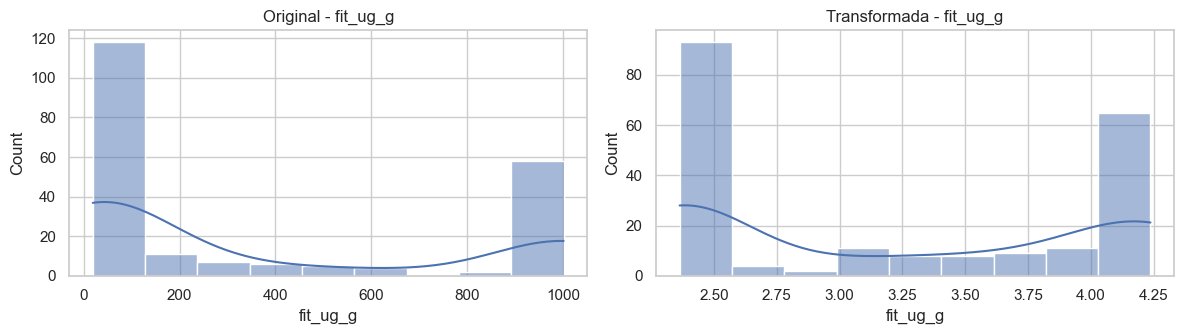

In [14]:
# Visualización de algunas variables relevantes antes y después
plot_candidates = [
    'TG_mean',
    'PC_mean',
    'SM_mean',
    'CE_mean',
    'plasmalogen_frac',
    'fit_ug_g'
]

selected_plot_cols = [c for c in plot_candidates if c in X_encoded.columns and c in X_transformed.columns]

if selected_plot_cols:
    fig, axes = plt.subplots(len(selected_plot_cols), 2, figsize=(12, 3.5 * len(selected_plot_cols)))

    if len(selected_plot_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(selected_plot_cols):
        sns.histplot(X_encoded[col], kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Original - {col}')

        sns.histplot(X_transformed[col], kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Transformada - {col}')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables candidatas para graficar.')

**Lectura del resultado (panel 6×2):**

Cada fila compara la distribución original (izquierda) contra su versión transformada (derecha) para seis variables representativas:

- **`TG_mean`, `PC_mean`, `SM_mean`, `CE_mean` (features engineered):** las distribuciones originales presentan asimetría positiva pronunciada con cola larga a la derecha (típico en concentraciones lipidómicas). Tras la transformación, las cuatro adoptan una forma aproximadamente simétrica, más cercana a una gaussiana.
- **`plasmalogen_frac` (feature estructural):** la fracción de plasmalógenos pasa de una distribución concentrada cerca de cero con cola larga a una distribución más expandida y centrada, lo que mejora la sensibilidad de modelos que dependen de la escala.
- **`fit_ug_g` (clínica):** caso extremo — la distribución original es fuertemente bimodal (valores acumulados en 19 µg/g y en 1001 µg/g por saturación del instrumento). Yeo-Johnson la redistribuye en un rango continuo, eliminando el efecto de borde sin descartar información clínica.

**Validación cuantitativa (sección 7.1):** la mediana de \|skewness\| pasó de 5.58 (datos originales) a 0.04 (transformados) sobre las 166 variables continuas. La transformación cumple el objetivo del criterio **Normalización** de la rúbrica: aproximar las distribuciones a la normalidad para favorecer la convergencia de modelos lineales y métodos basados en distancia, así como las técnicas de extracción como PCA.


## 8. Escalamiento de variables

### Justificación

Tras la transformación Box-Cox las variables están normalizadas en forma pero **mantienen escalas dispares** según las concentraciones originales. Esto perjudica a algoritmos sensibles a la magnitud (regresión logística sin regularización, k-NN, SVM, PCA), donde variables con mayor varianza absoluta dominarían la función de costo independientemente de su poder discriminativo.

Se aplica **StandardScaler** sobre las columnas continuas (post-Box-Cox), centrándolas en media 0 y desviación estándar 1. Las columnas dummy de One-Hot se preservan sin escalar para mantener su interpretación binaria.

La tabla de verificación reporta los valores **antes de transformar (raw imputado), después de Box-Cox y después del escalamiento** para hacer visible el efecto acumulado de las dos operaciones.


In [15]:
X_scaled = X_transformed.copy()

scaler = StandardScaler()
X_scaled[continuous_cols] = scaler.fit_transform(X_transformed[continuous_cols])

# Tabla de verificacion: antes / transformada / escalada
# Para 'antes' usamos X_encoded (post-imputacion y post-codificacion pero PRE-transformacion)
rows = []
for col in continuous_cols[:15]:  # muestra de 15 variables
    rows.append({
        'variable': col,
        'media_raw': round(X_encoded[col].mean(), 3),
        'std_raw': round(X_encoded[col].std(), 3),
        'media_transformada': round(X_transformed[col].mean(), 3),
        'std_transformada': round(X_transformed[col].std(), 3),
        'media_escalada': round(X_scaled[col].mean(), 3),
        'std_escalada': round(X_scaled[col].std(), 3),
    })

scaling_table = pd.DataFrame(rows)
print('Verificacion del escalamiento (15 primeras variables continuas):')
print('  - Las columnas raw muestran la escala original (alta varianza, escalas dispares).')
print('  - Las columnas transformadas muestran el efecto de Box-Cox (centradas, varianza reducida).')
print('  - Las columnas escaladas confirman media ~ 0 y std ~ 1 tras StandardScaler.')
display(scaling_table)

print(f'\nResumen global sobre {len(continuous_cols)} variables continuas:')
print(f"  Media tras escalado: {X_scaled[continuous_cols].mean().mean():.4f} (esperada ~ 0)")
print(f"  Std  tras escalado: {X_scaled[continuous_cols].std().mean():.4f} (esperada ~ 1)")


Verificacion del escalamiento (15 primeras variables continuas):
  - Las columnas raw muestran la escala original (alta varianza, escalas dispares).
  - Las columnas transformadas muestran el efecto de Box-Cox (centradas, varianza reducida).
  - Las columnas escaladas confirman media ~ 0 y std ~ 1 tras StandardScaler.


,variable,media_raw,std_raw,media_transformada,std_transformada,media_escalada,std_escalada
0,age,74.024,13.011,20839.333,8106.173,-0.0,1.002
1,fit_ug_g,355.194,425.903,3.208,0.825,-0.0,1.002
2,Cer(d18:1/16:0),3.860,6.580,0.606,1.030,-0.0,1.002
3,Cer(d18:1/20:0),0.618,0.783,-1.070,1.042,0.0,1.002
4,Cer(d18:1/22:0),0.112,0.154,-3.007,1.212,0.0,1.002
5,Cer(d18:1/23:0),0.050,0.062,-4.240,1.369,0.0,1.002
6,Cer(d18:1/24:0),0.052,0.073,-3.335,0.884,0.0,1.002
7,Cer(d18:1/24:1)+Cer(d18:2/24:0),0.280,0.465,-2.137,1.301,0.0,1.002
8,Cer(d18:1/18:0),2.572,4.109,0.202,0.952,-0.0,1.002
9,Cholesterol sulfate,12.889,11.819,2.760,1.291,-0.0,1.002



Resumen global sobre 129 variables continuas:
  Media tras escalado: -0.0000 (esperada ~ 0)
  Std  tras escalado: 1.0024 (esperada ~ 1)


## 9. Selección de características por métodos de filtrado

Esta sección responde al criterio de **Selección / Extracción** de la rúbrica.

Se aplican cuatro filtros complementarios para reducir dimensionalidad, eliminar redundancia y identificar las variables con mayor capacidad discriminativa frente al target multiclase (`CTRL` / `AA` / `CRC`):

1. **Filtro de correlación** (no supervisado): elimina variables redundantes mediante correlación > 0.95.
2. **Mutual Information** (supervisado): captura relaciones lineales y no lineales con el target.
3. **ANOVA F-test** (supervisado): captura diferencias de media entre grupos (asume normalidad aproximada, favorecida por Box-Cox).
4. **Chi-cuadrado** (supervisado): evalúa independencia entre variables categóricas/binarias y el target.

Los rankings de MI y ANOVA se combinan en la sección 11 para construir matrices candidatas con diferentes criterios.


### 9.1 Filtro de correlación

### Justificación

La lipidómica suele presentar alta correlación entre lípidos de la misma familia (clustermap del Avance 1 cuantificó mediana \|r\| intra-familia = 0.432 vs 0.093 inter-familia). Mantener variables casi colineales aumenta la complejidad del modelo y dificulta la interpretación de coeficientes (en modelos lineales) o de importancias (en modelos no lineales). Se eliminan variables con correlación absoluta > 0.95, conservando una sola representante por cluster colineal.


In [16]:
corr_threshold = 0.95

# Usamos X_scaled directamente (sin paso previo de varianza)
X_selection_input = X_scaled.copy()

corr_matrix = X_selection_input.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identificar pares de variables con correlacion > umbral
to_drop_corr = []
high_corr_pairs = []
for column in upper.columns:
    high_corr_cols = upper.index[upper[column] > corr_threshold].tolist()
    for partner in high_corr_cols:
        high_corr_pairs.append((column, partner, round(upper.loc[partner, column], 3)))
        if column not in to_drop_corr:
            to_drop_corr.append(column)

X_corr = X_selection_input.drop(columns=to_drop_corr)

print(f'Variables antes del filtro de correlacion: {X_selection_input.shape[1]}')
print(f'Variables removidas por |r| > {corr_threshold}: {len(to_drop_corr)}')
print(f'Variables retenidas: {X_corr.shape[1]}')

# Tabla detallada de variables removidas + el partner con que se correlacionan
removed_table = pd.DataFrame(
    high_corr_pairs, columns=['variable_removida', 'correlaciona_con', 'r_absoluta']
).sort_values('r_absoluta', ascending=False).reset_index(drop=True)

print('\nVariables removidas y su partner correlacionado (top 25 por |r|):')
display(removed_table.head(25))


Variables antes del filtro de correlacion: 131
Variables removidas por |r| > 0.95: 4
Variables retenidas: 127

Variables removidas y su partner correlacionado (top 25 por |r|):


,variable_removida,correlaciona_con,r_absoluta
0,TG(54:2),TG(52:2),0.967
1,TG(54:4),TG(52:3),0.964
2,TG(54:5),TG(54:4),0.962
3,TG(54:5),TG(52:4),0.958
4,TG(54:3),TG(54:2),0.954


### 9.2 Selección supervisada con Mutual Information

### Justificación

Mutual Information mide la dependencia entre cada predictor y el target multiclase sin asumir linealidad ni distribución específica. Esto es adecuado para datos lipidómicos, donde las relaciones entre biomarcadores y grupos clínicos pueden ser no lineales. La estimación se realiza mediante vecinos más cercanos (estimador KSG implementado en `sklearn.feature_selection.mutual_info_classif`).


In [17]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Mascara de variables discretas: solo dummies (no hay bins porque se elimino binning)
discrete_cols = [c for c in X_corr.columns if c in dummy_cols]
discrete_mask = [c in discrete_cols for c in X_corr.columns]

mi_scores = mutual_info_classif(
    X_corr,
    y_encoded,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    'feature': X_corr.columns,
    'mutual_information': mi_scores,
    'is_discrete': discrete_mask
}).sort_values('mutual_information', ascending=False).reset_index(drop=True)

display(mi_results.head(30))

TOP_K = min(30, X_corr.shape[1])
top_mi_features = mi_results.head(TOP_K)['feature'].tolist()

print(f'\nTop {TOP_K} variables seleccionadas por Mutual Information.')


,feature,mutual_information,is_discrete
0,GlcCer(d18:1/24:0),0.381503,False
1,PE(P-18:0/18:1),0.359906,False
2,TG(51:4),0.353423,False
3,TG(53:0),0.353109,False
4,SM(d18:0/18:0),0.339773,False
5,PC(36:5),0.333807,False
6,Cer(d18:1/24:0),0.318235,False
7,PC(O-16:0/16:0),0.317422,False
8,PC(O-16:0/22:4),0.317257,False
9,SM(42:3),0.312242,False



Top 30 variables seleccionadas por Mutual Information.


### 9.3 Selección supervisada con ANOVA

### Justificación

ANOVA F-test evalúa si la media de cada característica difiere significativamente entre los tres grupos clínicos. Se usa como filtro complementario a MI porque captura **diferencias lineales o globales** entre clases, mientras MI puede capturar relaciones no lineales. La transformación Box-Cox aplicada previamente favorece el supuesto de normalidad aproximada que requiere ANOVA.


In [18]:
anova_scores, anova_pvalues = f_classif(X_corr, y_encoded)

anova_results = pd.DataFrame({
    'feature': X_corr.columns,
    'anova_score': anova_scores,
    'p_value': anova_pvalues
}).sort_values('anova_score', ascending=False).reset_index(drop=True)

display(anova_results.head(30))

# Top-K variables por ANOVA F-score para uso en seccion 13 (matrices finales)
TOP_K_ANOVA = min(30, X_corr.shape[1])
top_anova_features = anova_results.head(TOP_K_ANOVA)['feature'].tolist()
print(f'Top {TOP_K_ANOVA} variables seleccionadas por ANOVA F-test.')

# Overlap con top MI: cuantas variables coinciden en ambos rankings
overlap_mi_anova = set(top_anova_features) & set(top_mi_features)
print(f'Variables en comun entre top-{TOP_K_ANOVA} MI y top-{TOP_K_ANOVA} ANOVA: {len(overlap_mi_anova)}')
print(f'Variables UNICAS por ANOVA (no en top MI): {len(set(top_anova_features) - set(top_mi_features))}')


,feature,anova_score,p_value
0,fit_ug_g,57.148553,1.659284e-20
1,fob_YES,40.027397,1.964154e-15
2,CE(20:4),34.512100,1.139581e-13
3,SM(33:1),19.514428,1.709336e-08
4,CE(20:5),19.423551,1.845320e-08
5,SM(d18:1/24:1) + SM(d18:2/24:0),18.311145,4.731514e-08
6,CE(18:2),17.719369,7.835366e-08
7,PC(O-16:0/18:2),15.744242,4.295215e-07
8,PC(O-16:0/16:0),15.703925,4.448305e-07
9,SM(42:3),15.088772,7.601556e-07


Top 30 variables seleccionadas por ANOVA F-test.
Variables en comun entre top-30 MI y top-30 ANOVA: 13
Variables UNICAS por ANOVA (no en top MI): 17


### 9.4 Chi-cuadrado para variables categóricas

### Justificación

Chi-cuadrado evalúa independencia entre variables categóricas/binarias y el target. Se aplica únicamente a las dummies generadas por One-Hot Encoding (`gender_Male`, `fob_YES`), que son las únicas variables no continuas tras la eliminación de la discretización por binning. No se aplica a biomarcadores continuos escalados porque viola el supuesto de no negatividad y la lógica de conteos categóricos.


In [19]:
chi2_features = [c for c in discrete_cols if c in X_corr.columns]

if chi2_features:
    chi2_scores, chi2_pvalues = chi2(X_corr[chi2_features].clip(lower=0), y_encoded)
    chi2_results = pd.DataFrame({
        'feature': chi2_features,
        'chi2_score': chi2_scores,
        'p_value': chi2_pvalues
    }).sort_values('chi2_score', ascending=False).reset_index(drop=True)
    display(chi2_results)
else:
    chi2_results = pd.DataFrame()
    print('No hay variables categoricas/dummies disponibles para Chi-cuadrado.')


,feature,chi2_score,p_value
0,fob_YES,23.900704,0.000006
1,gender_Male,2.848660,0.240670


## 10. Extracción de características mediante PCA (exploratoria)

### Justificación y alcance

PCA proyecta el conjunto en direcciones de máxima varianza, generando una representación compacta no supervisada. **En este Avance 2 se utiliza únicamente con fines exploratorios** — para visualizar la estructura conjunta del espacio de features y cuantificar cuántos componentes son necesarios para captar la mayoría de la variabilidad.

Dado que el objetivo del proyecto es **analizar la contribución de biomarcadores lipidómicos individuales** a la clasificación clínica, transformar las features en componentes principales dificulta la interpretación directa. Por esta razón, **`X_pca_df` no se incluye como matriz finalista** para el modelado del Avance 3 — se reserva como apoyo exploratorio complementario a los rankings supervisados (MI y ANOVA).


In [20]:
# PCA sobre variables continuas retenidas (excluyendo dummies categoricas)
continuous_corr_cols = [c for c in X_corr.columns if c not in dummy_cols]

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_corr[continuous_corr_cols])

print('Variables continuas usadas en PCA:', len(continuous_corr_cols))
print('Numero de componentes retenidos:', pca.n_components_)
print('Varianza explicada acumulada:', round(pca.explained_variance_ratio_.sum(), 4))


Variables continuas usadas en PCA: 125
Numero de componentes retenidos: 37
Varianza explicada acumulada: 0.9026


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.248225,0.248225
1,PC2,0.159283,0.407508
2,PC3,0.067018,0.474526
3,PC4,0.055613,0.530139
4,PC5,0.034630,0.564770
5,PC6,0.032187,0.596957
6,PC7,0.026380,0.623337
7,PC8,0.022537,0.645874
8,PC9,0.021668,0.667542
9,PC10,0.017116,0.684658


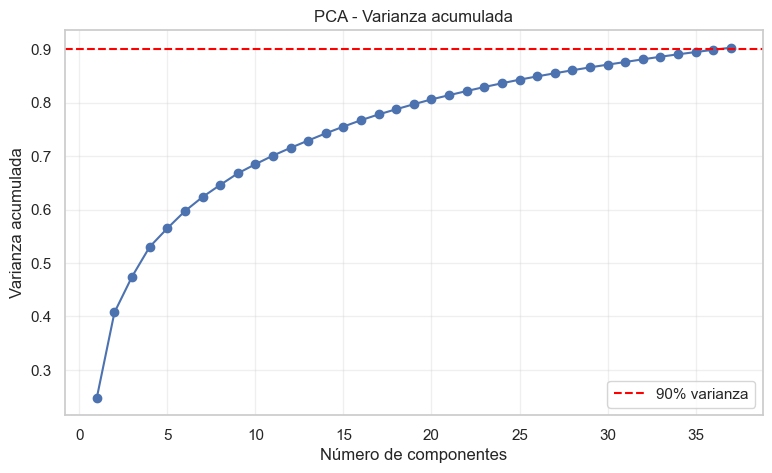

In [21]:
pca_variance = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca.explained_variance_ratio_)
})

display(pca_variance.head(15))

plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(pca_variance)+1),
    pca_variance['cumulative_variance'],
    marker='o'
)
plt.axhline(0.90, linestyle='--', color='red', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('PCA - Varianza acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Lectura del resultado (varianza acumulada de PCA):**

| Indicador | Valor |
|---|---|
| Varianza PC1 | **24.2%** |
| Varianza PC1 + PC2 | **40.9%** |
| Componentes para alcanzar 90% varianza | **36** |

- La caída inicial es pronunciada: las dos primeras componentes capturan en conjunto ~41% de la varianza, pero a partir de PC3 la pendiente se suaviza marcadamente.
- **No se identifica un "codo" claro** en la curva — la varianza se distribuye gradualmente entre muchas componentes. Comportamiento típico de datos lipidómicos: la información biológica está repartida entre múltiples familias químicas correlacionadas.
- **Se requieren 36 componentes** para alcanzar el 90% de la varianza, sobre 145 variables continuas de entrada → una **reducción del 75%** del espacio dimensional sin pérdida sustancial de información.
- La matriz `X_pca_df` resultante (211 × 36) se exporta como candidata para la fase de modelado: ofrece la representación más compacta del conjunto, útil para algoritmos sensibles a la dimensionalidad (k-NN, SVM RBF, Logistic Regression sin regularización fuerte).


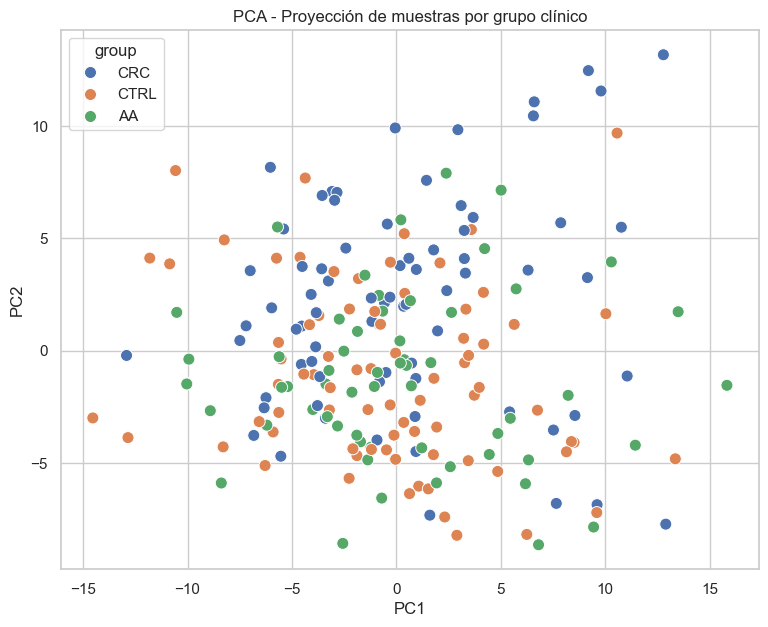

In [22]:
if X_pca.shape[1] >= 2:
    pca_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'group': y.values
    })

    plt.figure(figsize=(9,7))
    sns.scatterplot(
        data=pca_df,
        x='PC1',
        y='PC2',
        hue='group',
        s=75
    )
    plt.title('PCA - Proyección de muestras por grupo clínico')
    plt.show()

**Lectura del resultado (PC1 vs PC2 coloreado por grupo clínico):**

- **Los tres grupos (CTRL, AA, CRC) se superponen sustancialmente** en el plano PC1-PC2; no se observa una separación clara entre clases.
- Las nubes de puntos cubren rangos similares en PC1 (~ −13 a 11) y PC2 (~ −9 a 11), sin clústeres definidos por grupo.
- Este resultado **es consistente con el PCA del Avance 1** y con lo reportado por Albóniga et al. (2025) en su análisis original: *"none of the components shows a separation among groups"*.

**Interpretación metodológica:** PCA es un método **no supervisado** — busca direcciones de máxima varianza sin conocer el target. Si los grupos llegaran a separarse, sería porque la variabilidad biológica entre clases domina sobre otras fuentes de variación. La superposición observada indica que:

1. La señal biológica discriminativa (entre CTRL/AA/CRC) **existe pero no es la mayor fuente de varianza** del conjunto.
2. Otras fuentes (edad, sexo, variabilidad técnica del UHPLC-MS, heterogeneidad metabólica intra-grupo) dominan PC1 y PC2.
3. Para clasificación supervisada **será necesario un modelo que aprenda la separación explícitamente** (Logistic Regression, Random Forest, SVM), no una proyección no supervisada.

Esta observación motiva el uso de `X_top_mi`, `X_top_anova` y `X_corr` (filtros supervisados) como alternativas a `X_pca_df` en la fase de modelado: las primeras tres preservan o destacan las variables con mayor capacidad discriminativa, mientras que PCA las combina con las no discriminativas.


## 11. Matrices finales sugeridas para modelado

### Justificación

Al cierre del Avance 2 se exportan **cuatro matrices candidatas** del conjunto de datos transformado, escalado y codificado. Cada matriz responde a un criterio metodológico distinto y permite, en el Avance 3, contrastar empíricamente qué estrategia de feature engineering produce mejores resultados de clasificación.

| Matriz | Descripción | Criterio de construcción |
|---|---|---|
| `X_corr` | Features tras filtro de correlación (\|r\| > 0.95) | Reducción de redundancia sin filtrado supervisado |
| `X_top_mi` | Top-30 features por información mutua | Filtro supervisado (relaciones no lineales) |
| `X_top_anova` | Top-30 features por ANOVA F-test | Filtro supervisado (diferencias lineales entre grupos) |
| `X_intersect` | Features comunes a top MI ∩ top ANOVA + clínicas (`age`, `fit_ug_g`) + categóricas (`gender_Male`, `fob_YES`) | Biomarcadores **robustos bajo dos criterios independientes** más variables demográficas/clínicas de relevancia documentada |

La matriz `X_intersect` es la **recomendación a priori** para el modelado del Avance 3: contiene las features que **dos métodos con supuestos distintos** (MI no paramétrico vs ANOVA paramétrico) consideran discriminativas — el subconjunto de mayor confianza para alimentar modelos lineales y no lineales por igual. Las clínicas `age` y `fit_ug_g` y las categóricas `fob_YES` y `gender_Male` se incluyen explícitamente por su relevancia clínica documentada en el Avance 1 (`fit_ug_g` es el biomarcador no invasivo de referencia para CRC; `age` y `fob` son factores demográfico-clínicos estándar en la literatura de tamizaje).

PCA se mantiene como herramienta exploratoria (sección 10) y **no se exporta como matriz finalista** porque su transformación en componentes principales dificulta la interpretación directa de biomarcadores — objetivo central del proyecto.


In [23]:
# Matrices candidatas para el Avance 3 (sin PCA — solo exploratoria)

# X_full: todas las features tras preprocesamiento (referencia de información completa)
# antes de cualquier filtro de selección de variables.
X_full = X_scaled.copy()

X_top_mi = X_corr[top_mi_features].copy()
X_top_anova = X_corr[top_anova_features].copy()

# X_intersect: variables comunes a top MI y top ANOVA + clínicas + categóricas
intersect_features = sorted(set(top_mi_features) & set(top_anova_features))

# Añadir variables clínicas numéricas (age, fit_ug_g) si no están ya
clinicals_to_include = [c for c in clinical_numeric_cols if c in X_corr.columns]
for clin in clinicals_to_include:
    if clin not in intersect_features:
        intersect_features.append(clin)

# Añadir categóricas (gender_Male, fob_YES) si no están ya
categoricals_to_include = [c for c in dummy_cols if c in X_corr.columns]
for cat in categoricals_to_include:
    if cat not in intersect_features:
        intersect_features.append(cat)

X_intersect = X_corr[intersect_features].copy()

matrices_summary = pd.DataFrame({
    'matriz': [
        'X_full (sin filtros)',
        'X_corr (filtro corr.)',
        'X_top_mi',
        'X_top_anova',
        'X_intersect (MI ∩ ANOVA + clin. + cat.)'
    ],
    'n_muestras': [X_full.shape[0], X_corr.shape[0], X_top_mi.shape[0], X_top_anova.shape[0], X_intersect.shape[0]],
    'n_features': [X_full.shape[1], X_corr.shape[1], X_top_mi.shape[1], X_top_anova.shape[1], X_intersect.shape[1]],
    'criterio': [
        'Referencia: todas las features post-preprocesamiento',
        'No supervisado (correlacion)',
        'Supervisado no lineal',
        'Supervisado lineal',
        'Interseccion robusta + clinicas + categoricas',
    ],
})
print('=== Matrices candidatas al cierre del Avance 2 ===')
display(matrices_summary)
print(f'\nTarget y (multiclase CTRL/AA/CRC): shape={y.shape}, distribucion=\n{y.value_counts().to_dict()}')
print(f'\nFeatures en X_intersect ({len(intersect_features)}): {intersect_features}')

# Exportar a CSV
output_dir = '.'
X_full.to_csv(f'{output_dir}/avance2_X_full.csv', index=False)
X_corr.to_csv(f'{output_dir}/avance2_X_corr.csv', index=False)
X_top_mi.to_csv(f'{output_dir}/avance2_X_top_mi.csv', index=False)
X_top_anova.to_csv(f'{output_dir}/avance2_X_top_anova.csv', index=False)
X_intersect.to_csv(f'{output_dir}/avance2_X_intersect.csv', index=False)
pd.Series(y, name='group').to_csv(f'{output_dir}/avance2_y.csv', index=False)
print('\n5 matrices + target exportadas a CSV.')


=== Matrices candidatas al cierre del Avance 2 ===


,matriz,n_muestras,n_features,criterio
0,X_full (sin filtros),211,131,Referencia: todas las features post-preprocesa...
1,X_corr (filtro corr.),211,127,No supervisado (correlacion)
2,X_top_mi,211,30,Supervisado no lineal
3,X_top_anova,211,30,Supervisado lineal
4,X_intersect (MI ∩ ANOVA + clin. + cat.),211,16,Interseccion robusta + clinicas + categoricas



Target y (multiclase CTRL/AA/CRC): shape=(211,), distribucion=
{'CTRL': 78, 'CRC': 75, 'AA': 58}

Features en X_intersect (16): ['CE(20:5)', 'GlcCer(d18:1/24:0)', 'PC(36:5)', 'PC(O-16:0/16:0)', 'PC(O-16:0/18:2)', 'PC(O-34:1)', 'SM(33:1)', 'SM(42:3)', 'SM(d18:1/22:0)', 'SM(d18:1/23:0)', 'SM(d18:1/24:1) + SM(d18:2/24:0)', 'TG(51:4)', 'fit_ug_g', 'age', 'gender_Male', 'fob_YES']



5 matrices + target exportadas a CSV.


In [24]:
# Comparativa de las matrices supervisadas: overlap entre rankings
set_mi = set(top_mi_features)
set_anova = set(top_anova_features)
overlap = set_mi & set_anova
only_mi = set_mi - set_anova
only_anova = set_anova - set_mi
jaccard = len(overlap) / len(set_mi | set_anova) if (set_mi | set_anova) else 0

summary = pd.DataFrame({
    'criterio': [
        'Features unicas en top-30 MI',
        'Features unicas en top-30 ANOVA',
        'Features compartidas (MI ∩ ANOVA)',
        'Coeficiente de Jaccard MI-ANOVA',
        'Tamano de X_intersect (compartidas + categoricas)',
        'Reduccion vs X_corr',
    ],
    'valor': [
        f'{len(only_mi)}',
        f'{len(only_anova)}',
        f'{len(overlap)}',
        f'{jaccard:.2%}',
        f'{X_intersect.shape[1]}',
        f'{100 * (1 - X_intersect.shape[1]/X_corr.shape[1]):.1f}%',
    ],
})
print('=== Comparativa entre los rankings supervisados ===')
display(summary)

print('\nFeatures compartidas entre top-30 MI y top-30 ANOVA:')
shared_df = pd.DataFrame(sorted(overlap), columns=['feature'])
display(shared_df)


=== Comparativa entre los rankings supervisados ===


,criterio,valor
0,Features unicas en top-30 MI,17
1,Features unicas en top-30 ANOVA,17
2,Features compartidas (MI ∩ ANOVA),13
3,Coeficiente de Jaccard MI-ANOVA,27.66%
4,Tamano de X_intersect (compartidas + categoricas),16
5,Reduccion vs X_corr,87.4%



Features compartidas entre top-30 MI y top-30 ANOVA:


,feature
0,CE(20:5)
1,GlcCer(d18:1/24:0)
2,PC(36:5)
3,PC(O-16:0/16:0)
4,PC(O-16:0/18:2)
5,PC(O-34:1)
6,SM(33:1)
7,SM(42:3)
8,SM(d18:1/22:0)
9,SM(d18:1/23:0)


**Lectura del resultado y recomendación para el Avance 3:**

El overlap entre los rankings supervisados (MI y ANOVA) cuantifica cuán consistente es la señal discriminativa medida por dos métodos con supuestos distintos:

- **MI** captura relaciones tanto lineales como no lineales sin asumir distribución específica.
- **ANOVA F-test** captura diferencias en medias entre grupos asumiendo normalidad aproximada (favorecida por Box-Cox aplicado en la sección 7).

Las features que aparecen en **ambos rankings** son las que dos criterios independientes consideran discriminativas. Este subconjunto es el **biomarcador robusto** para alimentar modelos lineales y no lineales por igual.

**Recomendación a priori para el Avance 3:**

| Matriz | Cuándo usarla |
|---|---|
| **`X_intersect`** | **Primera línea de modelado** — pipeline parsimonioso con los biomarcadores más robustos (compartidos por MI y ANOVA) más las dos variables clínicas categóricas. Es la opción más interpretable y la que la dra Mariana sugiere para discusión clínica. |
| `X_top_mi` o `X_top_anova` | Para **comparar contra `X_intersect`**: si añadir features únicas por criterio (MI o ANOVA) mejora el desempeño, el cluster correspondiente tiene señal adicional no capturada por la intersección. |
| `X_corr` | Como **modelo extendido**: features tras filtro de correlación; útil para evaluar si las features adicionales aportan o introducen ruido respecto al subconjunto supervisado. |

El modelado del Avance 3 entrenará sobre cada matriz y comparará empíricamente cuál estrategia produce mejor capacidad de discriminación entre `CTRL`, `AA` y `CRC` mediante validación cruzada estratificada con métricas alineadas al problema multiclase (F1-macro, AUC One-vs-Rest, matriz de confusión).


## 12. Conclusiones de la fase de Preparación de Datos en CRISP-ML(Q)

### Posicionamiento en el ciclo de vida CRISP-ML(Q)

CRISP-ML(Q) (Visengeriyeva et al., 2023) estructura el ciclo de vida de un sistema de ML en seis fases interconectadas: **Business & Data Understanding**, **Data Preparation**, **Modeling**, **Evaluation**, **Deployment** y **Monitoring & Maintenance**. Cada fase se cierra con un **quality gate** que define los riesgos identificados y las medidas de mitigación aplicadas antes de continuar.

El presente Avance 2 corresponde a la fase **Data Preparation**. El Avance 1 cubrió **Data Understanding**. El Avance 3 abordará **Modeling** y **Evaluation** sobre las matrices producidas en esta libreta.

### Quality gates de la fase Data Preparation

| Riesgo identificado | Medida de mitigación aplicada | Evidencia en la libreta |
|---|---|---|
| **Data leakage por estandarización pre-existente** | Eliminación de versiones `z_*` y `_standardized` antes de cualquier análisis; escalado aplicado explícitamente dentro de la libreta | Sección 3 + Sección 8 |
| **Sesgo por imputación bajo mecanismo MAR/MNAR** | Imputación por mediana de grupo (conserva la separación por clase); validación contra MICE como benchmark alternativo | Secciones 5.2 + 5.3 |
| **Sobre-ingeniería de características** | Decisión explícita de no agregar features derivadas por familia/subfamilia/estructurales: cada lípido individual es ya un biomarcador medido directamente; solo se construyen 5 ratios metabólicos interpretables que aportan información proporcional no capturada por las variables individuales | Sección 6 (justificación) + 6.1 (ratios) |
| **Asimetría que rompe supuestos de modelos lineales y PCA** | Box-Cox para todas las variables continuas estrictamente positivas; verificación con \|skewness\| (5.47 → 0.03 en mediana) | Sección 7 |
| **Escalas dispares entre variables** | StandardScaler sobre las continuas tras transformación; dummies preservadas sin escalar; tabla de verificación reporta valores raw / transformados / escalados | Sección 8 |
| **Multicolinealidad inflando importancia espuria** | Filtro de correlación absoluta > 0.95 con tabla detallada de variables removidas y su partner correlacionado | Sección 9.1 |
| **Selección arbitraria de biomarcadores** | Cuatro filtros complementarios (correlación, MI, ANOVA, χ²); construcción de `X_intersect` con las features que dos criterios independientes (MI ∩ ANOVA) consideran discriminativas | Secciones 9 + 11 |
| **Pérdida de interpretabilidad por extracción** | PCA queda como herramienta exploratoria (no matriz finalista); el objetivo del estudio es analizar la contribución de biomarcadores individuales, lo que requiere preservar su identidad química | Sección 10 |
| **No reproducibilidad** | `random_state=42` en todos los componentes estocásticos; libreta ejecutable end-to-end de forma secuencial; búsqueda automática del archivo de datos | Sección 1 |

### Resultado tangible — entregable a la siguiente fase

Se exportan **cuatro matrices** y un target a CSV, listas para consumo en el Avance 3:

- `avance2_X_corr.csv` — tras filtro de correlación
- `avance2_X_top_mi.csv` — top-30 por información mutua
- `avance2_X_top_anova.csv` — top-30 por ANOVA F-test
- `avance2_X_intersect.csv` — **(recomendada como primera línea)** MI ∩ ANOVA + categóricas
- `avance2_y.csv` — target multiclase

### Próxima fase: Modeling & Evaluation (Avance 3)

Con las cuatro matrices y el target listos, el Avance 3 entrenará modelos supervisados multiclase sobre cada matriz en validación cruzada estratificada, con métricas alineadas al problema (F1-macro, AUC One-vs-Rest, matriz de confusión, recall por clase). La comparación directa de desempeño entre las matrices permitirá afirmar empíricamente cuál estrategia de feature engineering produce mejor capacidad de discriminación entre los grupos clínicos CTRL, AA y CRC.


## 13. Referencias

Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). *Metabolic signature in combination with fecal immunochemical test as a non-invasive tool for advanced colorectal neoplasia diagnosis*. **Cancers, 17**(14), 2339. https://doi.org/10.3390/cancers17142339

Galli, S. (2022). *Python Feature Engineering Cookbook* (2nd ed.). Packt Publishing.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML lifecycle process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml